In [1]:
import os
import random
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
from Fastkan import FastKAN

In [3]:
number_of_primitives = 3
visible_range = True#Use False to select entire spectrum
include_shadows = True
no_of_epochs = 30
#Visible range of pavia dataset has 66 bands and full spectrum has 103 bands
no_of_bands = 66 if visible_range else 103
output_classes = 9 if include_shadows else 8

# Loading Pavia Univeristy Dataset

In [4]:
hsi = scipy.io.loadmat("PaviaU.mat")
image = hsi["paviaU"]

gt = scipy.io.loadmat("PaviaU_gt.mat")
index = gt["paviaU_gt"]
image  =image[:, :, :no_of_bands]

print(image.shape)
print(index.shape)

(610, 340, 66)
(610, 340)


In [5]:
#Normalizing the image
max_val = np.max(image)
normalized_image = image.astype(np.float32) / max_val

In [6]:
image_for_training = normalized_image[:,:,:no_of_bands]
print(image_for_training.shape)

(610, 340, 66)


#   Dataset for Training 

In [7]:
x = []
for i in range(len(image_for_training)):
    for j in range(len(image_for_training[0])):
        if (index[i][j] == 0) or (index[i][j] == 9 and (not include_shadows)): #Ignoring all unclassified pixels
            continue
        x.append(image_for_training[i][j])

x = np.asarray(x,dtype=np.float32)
print(x.shape)

(42776, 66)


In [8]:
y = []

for i in range(len(image)):
    for j in range(len(image[0])):
        if index[i][j] == 0 or \
           (index[i][j] == 9 and (not include_shadows)):
            continue

        y.append(index[i][j]-1)

y = np.asarray(y , dtype=np.int64)
y.shape

(42776,)

In [9]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.2 MB 5.6 MB/s eta 0:00:02
   ----- ---------------------------------- 1.0/8.2 MB 5.6 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.2 MB 3.2 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.2 MB 3.2 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.2 MB 3.2 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.2 MB 3.2 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.2 MB 1.6 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.2 MB 1.6 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.2 MB 1.6 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.2 MB 1.6 MB/s eta 0:00:04
   ------------ --------


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from sklearn.model_selection import train_test_split
x_train , x_test ,y_train , y_test =train_test_split(x , y , test_size =0.25 , stratify =y)
print("Training shape :" , x_train.shape , y_train.shape)
print("Testing shape :" , x_test.shape , y_test.shape)

Training shape : (32082, 66) (32082,)
Testing shape : (10694, 66) (10694,)


# Model Defination

In [11]:
class ColorFastKAN(nn.Module):

    def __init__( self, no_of_bands,number_of_primitives,output_classes,):
        super().__init__()
        self.primitives = nn.ModuleList([
            FastKAN(
                layers_hidden=[no_of_bands, 1])
            for _ in range(number_of_primitives)
        ])
        self.classifier_kan = FastKAN(layers_hidden =[number_of_primitives,output_classes], )

    def forward(self, x):
        primitive_outputs = [
            primitive(x)
            for primitive in self.primitives]
        merged = torch.cat(primitive_outputs ,dim=1)
        kan_logits = self.classifier_kan(merged)
        return kan_logits
model = ColorFastKAN(no_of_bands=no_of_bands,number_of_primitives=number_of_primitives,output_classes=output_classes)

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters()
)


In [13]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

model = model.to(device)

Using device: cpu


In [14]:
print(model)

ColorFastKAN(
  (primitives): ModuleList(
    (0-2): 3 x FastKAN(
      (layers): ModuleList(
        (0): Fast_KANLinear(
          (layernorm): LayerNorm((66,), eps=1e-05, elementwise_affine=True, bias=True)
          (rbf): RadialBasisFunction()
          (spline_linear): SplineLinear(in_features=528, out_features=1, bias=False)
          (base_linear): Linear(in_features=66, out_features=1, bias=True)
        )
      )
    )
  )
  (classifier_kan): FastKAN(
    (layers): ModuleList(
      (0): Fast_KANLinear(
        (layernorm): LayerNorm((3,), eps=1e-05, elementwise_affine=True, bias=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=24, out_features=9, bias=False)
        (base_linear): Linear(in_features=3, out_features=9, bias=True)
      )
    )
  )
)


In [15]:
from torchinfo import summary
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

model = model.to(device)

summary(
    model,
    input_size=(1, no_of_bands))

optimizer = torch.optim.Adam(
    model.parameters(),)

criterion = nn.CrossEntropyLoss()

x_train_tensor = torch.tensor( x_train,dtype=torch.float32)

y_train_tensor = torch.tensor( y_train,dtype=torch.long)
x_test_tensor = torch.tensor(x_test , dtype =torch.float32)
y_test_tensor = torch.tensor(y_test , dtype =torch.long)
train_dataset = TensorDataset(x_train_tensor,y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

batch_size = 32

train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

loss_history = []
accuracy_history = []

for epoch in range(no_of_epochs):

    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()

        output = model(batch_x)

        loss = criterion(output,batch_y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

        predictions = torch.argmax(output,dim=1)

        total_correct += ( predictions == batch_y).sum().item()

        total_samples += batch_y.size(0)

    epoch_loss = total_loss / total_samples

    epoch_accuracy = (total_correct / total_samples
    )

    loss_history.append(
        epoch_loss
    )

    accuracy_history.append(
        epoch_accuracy
    )

    print(
        f"Epoch [{epoch+1}/{no_of_epochs}] | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

Using device: cpu
Epoch [1/30] | Loss: 0.9852 | Accuracy: 0.6592
Epoch [2/30] | Loss: 0.6500 | Accuracy: 0.7592
Epoch [3/30] | Loss: 0.6133 | Accuracy: 0.7759
Epoch [4/30] | Loss: 0.5818 | Accuracy: 0.7870
Epoch [5/30] | Loss: 0.5640 | Accuracy: 0.7958
Epoch [6/30] | Loss: 0.5443 | Accuracy: 0.8030
Epoch [7/30] | Loss: 0.5314 | Accuracy: 0.8074
Epoch [8/30] | Loss: 0.5216 | Accuracy: 0.8110
Epoch [9/30] | Loss: 0.5159 | Accuracy: 0.8129
Epoch [10/30] | Loss: 0.5114 | Accuracy: 0.8139
Epoch [11/30] | Loss: 0.4979 | Accuracy: 0.8182
Epoch [12/30] | Loss: 0.5019 | Accuracy: 0.8144
Epoch [13/30] | Loss: 0.4904 | Accuracy: 0.8218
Epoch [14/30] | Loss: 0.4911 | Accuracy: 0.8215
Epoch [15/30] | Loss: 0.4844 | Accuracy: 0.8230
Epoch [16/30] | Loss: 0.4800 | Accuracy: 0.8245
Epoch [17/30] | Loss: 0.4824 | Accuracy: 0.8243
Epoch [18/30] | Loss: 0.4839 | Accuracy: 0.8248
Epoch [19/30] | Loss: 0.4744 | Accuracy: 0.8277
Epoch [20/30] | Loss: 0.4747 | Accuracy: 0.8269
Epoch [21/30] | Loss: 0.4728 | 

In [16]:
model.eval()

test_correct = 0
test_samples = 0
test_loss = 0.0

with torch.no_grad():

    for batch_x, batch_y in test_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        output = model(batch_x)

        loss = criterion(output,batch_y)

        test_loss += (
            loss.item() * batch_x.size(0)
        )

        predictions = torch.argmax(
            output,
            dim=1
        )

        test_correct += (
            predictions == batch_y
        ).sum().item()

        test_samples += batch_y.size(0)

test_loss = test_loss / test_samples
test_accuracy = test_correct / test_samples

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.4778
Test Accuracy: 0.8246


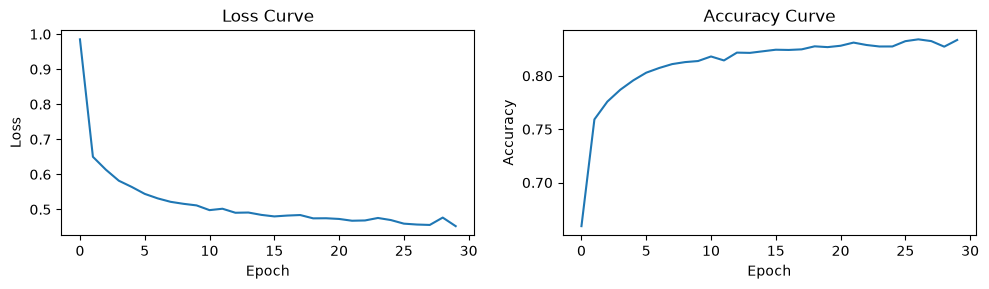

In [18]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(accuracy_history)
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# Plot each learned Filters

In [ ]:
wavelength = np.linspace(430, 860, 66) #430 - 860 is range of paviaU dataset and 103 is number of bands
wavelength_int = wavelength.astype(int)
print(wavelength_int)

[430 436 443 449 456 463 469 476 482 489 496 502 509 516 522 529 535 542
 549 555 562 568 575 582 588 595 602 608 615 621 628 635 641 648 654 661
 668 674 681 688 694 701 707 714 721 727 734 740 747 754 760 767 774 780
 787 793 800 807 813 820 826 833 840 846 853 860]


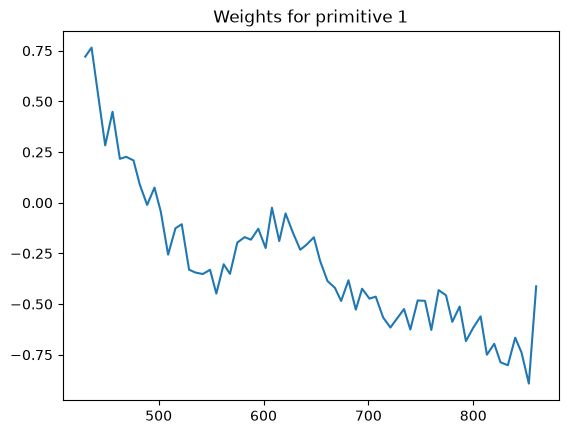

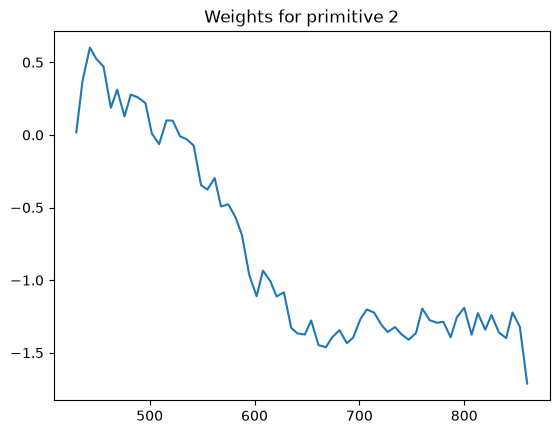

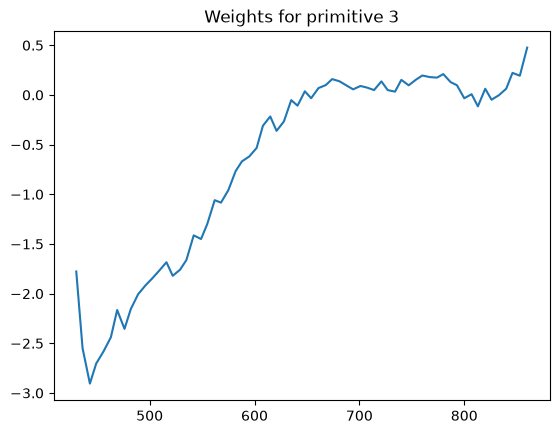

In [ ]:
primitive_curves = []

for primitive_no in range(number_of_primitives):

    p = (model.primitives[primitive_no].layers[0] .base_linear.weight .detach().cpu().numpy().flatten())

    primitive_curves.append(p)

    plt.plot(wavelength_int[:no_of_bands],p)

    plt.title(f"Weights for primitive {primitive_no + 1}")

    plt.show()

In [ ]:
for i, primitive in enumerate(model.primitives):

    w = (primitive.layers[0].base_linear.weight.detach().cpu().numpy())
    print(i + 1,f"primitive_{i + 1}", w[0, 0])

1 primitive_1 0.72088504
2 primitive_2 0.016888797
3 primitive_3 -1.7771832


In [ ]:
for i, (name, parameter) in enumerate(model.named_parameters()):
    if parameter.requires_grad:
        print(i, name, parameter.shape)

0 primitives.0.layers.0.layernorm.weight torch.Size([66])
1 primitives.0.layers.0.layernorm.bias torch.Size([66])
2 primitives.0.layers.0.spline_linear.weight torch.Size([1, 528])
3 primitives.0.layers.0.base_linear.weight torch.Size([1, 66])
4 primitives.0.layers.0.base_linear.bias torch.Size([1])
5 primitives.1.layers.0.layernorm.weight torch.Size([66])
6 primitives.1.layers.0.layernorm.bias torch.Size([66])
7 primitives.1.layers.0.spline_linear.weight torch.Size([1, 528])
8 primitives.1.layers.0.base_linear.weight torch.Size([1, 66])
9 primitives.1.layers.0.base_linear.bias torch.Size([1])
10 primitives.2.layers.0.layernorm.weight torch.Size([66])
11 primitives.2.layers.0.layernorm.bias torch.Size([66])
12 primitives.2.layers.0.spline_linear.weight torch.Size([1, 528])
13 primitives.2.layers.0.base_linear.weight torch.Size([1, 66])
14 primitives.2.layers.0.base_linear.bias torch.Size([1])
15 classifier_kan.layers.0.layernorm.weight torch.Size([3])
16 classifier_kan.layers.0.layernor

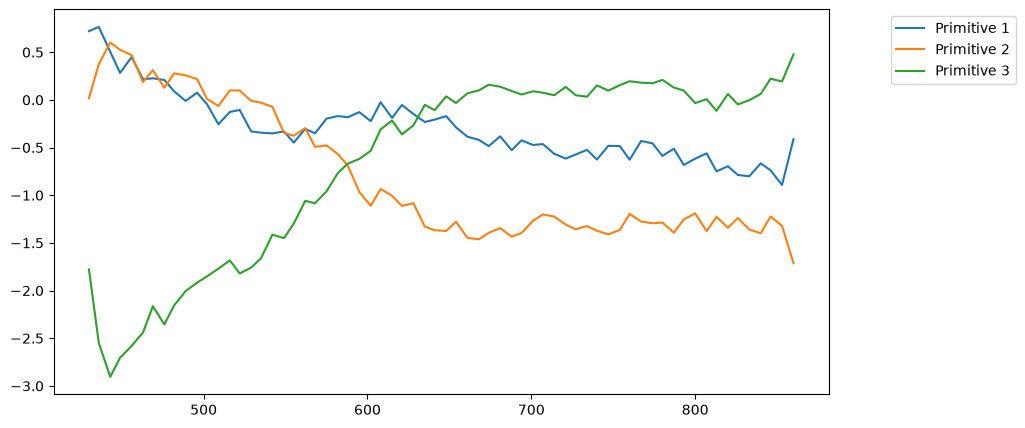

In [ ]:
plt.figure(figsize=(10, 5))

for primitive_no in range(number_of_primitives):

    plt.plot(wavelength_int[:no_of_bands],primitive_curves[primitive_no],label=f"Primitive {primitive_no + 1}")
plt.legend(bbox_to_anchor=(1.25, 1))
plt.show()


In [ ]:
model_name = (
    f'{no_of_bands}bands_'f'{number_of_primitives}primitives_' f'{"with_shadow" if include_shadows else "without_shadow"}_' f'fastkan_random_init')

In [ ]:
print(model_name)

66bands_3primitives_with_shadow_fastkan_random_init


In [ ]:
torch.save(model.state_dict(), f"{model_name}.pth")

In [ ]:
model = ColorFastKAN(
    no_of_bands,
    number_of_primitives,
    output_classes
)

model.load_state_dict(torch.load(f"{model_name}.pth"))
model.eval()

ColorFastKAN(
  (primitives): ModuleList(
    (0-2): 3 x FastKAN(
      (layers): ModuleList(
        (0): Fast_KANLinear(
          (layernorm): LayerNorm((66,), eps=1e-05, elementwise_affine=True, bias=True)
          (rbf): RadialBasisFunction()
          (spline_linear): SplineLinear(in_features=528, out_features=1, bias=False)
          (base_linear): Linear(in_features=66, out_features=1, bias=True)
        )
      )
    )
  )
  (classifier_kan): FastKAN(
    (layers): ModuleList(
      (0): Fast_KANLinear(
        (layernorm): LayerNorm((3,), eps=1e-05, elementwise_affine=True, bias=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=24, out_features=9, bias=False)
        (base_linear): Linear(in_features=3, out_features=9, bias=True)
      )
    )
  )
)

#Generate Image

In [ ]:
def predict_image():
    x_pred = image_for_training.reshape(-1, no_of_bands)

    print("Prediction Input Shape:", x_pred.shape)
    print("Predicting...")

    x_pred = torch.tensor( x_pred,dtype=torch.float32, device=device)

    model.eval()

    with torch.no_grad():

        primitive_outputs = []

        for primitive in model.primitives:
            primitive_outputs.append(primitive(x_pred))
        prediction = torch.cat(primitive_outputs,dim=1)

    prediction = prediction.cpu().numpy()

    predicted_image = prediction.reshape(
        image.shape[0],
        image.shape[1],
        number_of_primitives
    )

    return predicted_image
def normalize_images(predicted_image, channels):

    max_val = np.max(predicted_image)

    if max_val == 0:
        min_max_normalized_image = predicted_image.copy()
    else:
        min_max_normalized_image = predicted_image / max_val
    normalized_channel_image = np.zeros_like(predicted_image)

    for i in range(predicted_image.shape[-1]):

        channel = predicted_image[:, :, i]

        channel_max = np.max(np.abs(channel))

        if channel_max != 0:
            normalized_channel_image[:, :, i] = (
                channel / channel_max
            )
        else:
            normalized_channel_image[:, :, i] = channel
    clipped_image = np.clip(
        predicted_image,0,1)
    c1, c2, c3 = [c - 1 for c in channels]

    rgb_minmax = np.dstack((
        min_max_normalized_image[:, :, c1],
        min_max_normalized_image[:, :, c2],
        min_max_normalized_image[:, :, c3]
    ))

    rgb_channelwise = np.dstack((
        normalized_channel_image[:, :, c1],
        normalized_channel_image[:, :, c2],
        normalized_channel_image[:, :, c3]
    ))

    rgb_clipped = np.dstack((
        clipped_image[:, :, c1],
        clipped_image[:, :, c2],
        clipped_image[:, :, c3]
    ))

    return [
        rgb_minmax,
        rgb_channelwise,
        rgb_clipped
    ]

Prediction Input Shape: (207400, 66)
Predicting...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.326776..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.6743273].


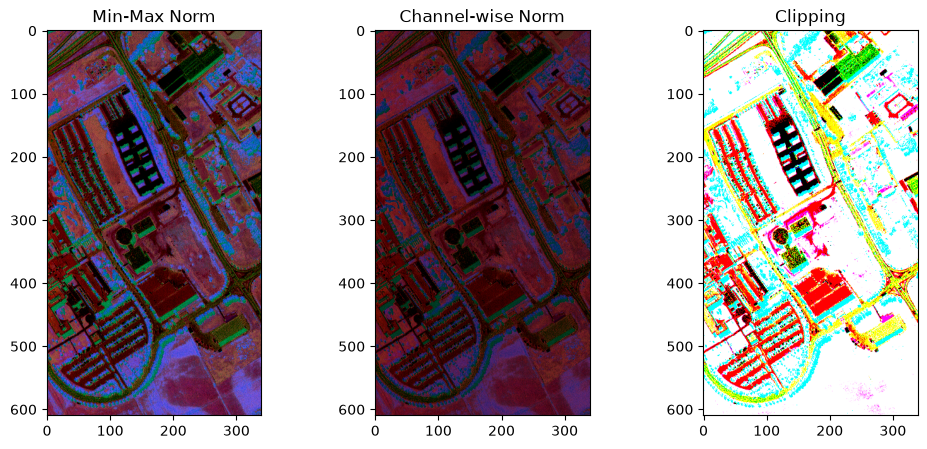

In [ ]:
channels = [1, 2, 3]

predicted_image = predict_image()

normalized_images = normalize_images(
    predicted_image,
    channels
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(normalized_images[0])
plt.title("Min-Max Norm")

plt.subplot(1, 3, 2)
plt.imshow(normalized_images[1])
plt.title("Channel-wise Norm")

plt.subplot(1, 3, 3)
plt.imshow(normalized_images[2])
plt.title("Clipping")

plt.show()